In [130]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nazishjaveed/california-house-price-prediction/california_housing_test_1.csv


In [131]:
import pandas as pd 
import numpy as np

In [132]:
data=pd.read_csv("/kaggle/input/datasets/nazishjaveed/california-house-price-prediction/california_housing_test_1.csv")

In [133]:
data.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,Unnamed: 9,ocean_proximity
0,-122.05,37.37,27,3885,661,1537,606,6.6085,344700,NaN,NEAR BAY
1,-118.30,34.26,43,1510,310,809,277,3.5990,176500,NaN,NEAR BAY
2,-117.81,33.78,27,3589,507,1484,495,5.7934,270500,NaN,NEAR BAY
3,-118.36,33.82,28,67,15,49,11,6.1359,330000,NaN,NEAR BAY
4,-119.67,36.33,19,1241,244,850,237,2.9375,81700,NaN,NEAR BAY


In [134]:
data.drop(columns=["Unnamed: 9"],axis=1,inplace=True)

In [135]:
data.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.05,37.37,27,3885,661,1537,606,6.6085,344700,NEAR BAY
1,-118.30,34.26,43,1510,310,809,277,3.5990,176500,NEAR BAY
2,-117.81,33.78,27,3589,507,1484,495,5.7934,270500,NEAR BAY
3,-118.36,33.82,28,67,15,49,11,6.1359,330000,NEAR BAY
4,-119.67,36.33,19,1241,244,850,237,2.9375,81700,NEAR BAY


In [136]:
data.isnull().sum()

longitude                0
latitude                 0
housing_median_age       0
total_rooms              0
total_bedrooms           0
population               0
households               0
median_income            0
median_house_value       0
ocean_proximity       2426
dtype: int64

In [137]:
data["ocean_proximity"].value_counts()

ocean_proximity
NEAR BAY    574
Name: count, dtype: int64

In [138]:
data=pd.get_dummies(data,columns=["ocean_proximity"],dtype=int)

In [139]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_NEAR BAY
0,-122.05,37.37,27,3885,661,1537,606,6.6085,344700,1
1,-118.30,34.26,43,1510,310,809,277,3.5990,176500,1
2,-117.81,33.78,27,3589,507,1484,495,5.7934,270500,1
3,-118.36,33.82,28,67,15,49,11,6.1359,330000,1
4,-119.67,36.33,19,1241,244,850,237,2.9375,81700,1


In [140]:
x=data.drop(columns=["median_house_value"],axis=1)

In [141]:
x

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_NEAR BAY
0,-122.05,37.37,27,3885,661,1537,606,6.6085,1
1,-118.30,34.26,43,1510,310,809,277,3.5990,1
2,-117.81,33.78,27,3589,507,1484,495,5.7934,1
3,-118.36,33.82,28,67,15,49,11,6.1359,1
4,-119.67,36.33,19,1241,244,850,237,2.9375,1
...,...,...,...,...,...,...,...,...,...
2995,-119.86,34.42,23,1450,642,1258,607,1.1790,0
2996,-118.14,34.06,27,5257,1082,3496,1036,3.3906,0
2997,-119.70,36.30,10,956,201,693,220,2.2895,0
2998,-117.12,34.10,40,96,14,46,14,3.2708,0


In [142]:
y=data["median_house_value"]

In [143]:
y

0       344700
1       176500
2       270500
3       330000
4        81700
         ...  
2995    225000
2996    237200
2997     62000
2998    162500
2999    500001
Name: median_house_value, Length: 3000, dtype: int64

In [144]:
from sklearn.model_selection import train_test_split

In [145]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [146]:
from sklearn.preprocessing import StandardScaler

In [147]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [148]:
from sklearn.linear_model import LinearRegression

In [149]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [150]:
y_pred=model.predict(x_test)

In [151]:
y_pred

array([ 126938.03101757,  146275.56221828,  247573.07615558,
        205362.41144332,  195202.59828189,  175821.98418136,
        230078.78339386,  164013.38459271,   67841.42362302,
        197319.22406218,  163009.45824666,  220668.80972212,
         31305.16403086,  271287.06974466,  137629.2204413 ,
        342303.26990209,   30524.00367875,  115272.56217927,
        343836.76656447,  238612.88229199,  248331.34108783,
        172099.13636554,  365793.82373337,  123066.51031115,
        152746.08018116,  259770.35507666,  212056.19732543,
         54454.41292025,  303240.94918164,  155605.38291791,
        336714.00091009,  120965.53366164,  124345.76968344,
        266147.93417602,  203562.1213183 ,  333616.16585617,
        159190.57041243,  241287.40093439,  240771.86056826,
        291898.93714062,  186458.48672686,   34336.50468482,
        180027.87302405,   99923.41863395,  124127.46824448,
        265170.23565282,  125437.21842316,  270835.00941379,
        257217.70980585,

In [152]:
from sklearn.metrics import r2_score

In [153]:
print(r2_score(y_test,y_pred))

0.635942350392242


In [154]:
from sklearn.ensemble import RandomForestRegressor

In [155]:
Model=RandomForestRegressor(n_estimators=300,max_depth=20,random_state=42)

In [156]:
Model.fit(x_train,y_train)


RandomForestRegressor(max_depth=20, n_estimators=300, random_state=42)

In [157]:
y_pred=model.predict(x_test)

In [158]:
from sklearn.metrics import r2_score

In [159]:
print(r2_score(y_test,y_pred))

0.635942350392242


In [160]:
from sklearn.ensemble import GradientBoostingRegressor

In [161]:
modell=GradientBoostingRegressor(n_estimators=200,max_depth=5,learning_rate=0.1,random_state=42)

In [162]:
modell.fit(x_train,y_train)

GradientBoostingRegressor(max_depth=5, n_estimators=200, random_state=42)

In [163]:
y_pred=modell.predict(x_test)

In [164]:
from sklearn.metrics import r2_score

In [165]:
print(r2_score(y_test,y_pred))

0.7525169827964181


In [166]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [167]:
model=Sequential()
model.add(Dense(64,activation='relu',input_dim=(x_train.shape[1])))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [168]:
model.compile(loss='mse',optimizer='adam',metrics=['accuracy'])

In [169]:
model.fit(x_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 55014518784.0000 - val_accuracy: 0.0000e+00 - val_loss: 52968660992.0000
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 55537537024.0000 - val_accuracy: 0.0000e+00 - val_loss: 52958720000.0000
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 58295001088.0000 - val_accuracy: 0.0000e+00 - val_loss: 52932177920.0000
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 57998774272.0000 - val_accuracy: 0.0000e+00 - val_loss: 52878417920.0000
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 58365108224.0000 - val_accuracy: 0.0000e+00 - val_loss: 52785164288.0000
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 55231209472.0000 - val_accuracy: 0.0000e+00 - val_loss: 52642750464.0000
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - l

In [170]:
from sklearn.metrics import r2_score,mean_squared_error

In [171]:
print("ANN r2_score=",r2_score(y_test,y_pred))
print("ANN MSE=",mean_squared_error(y_test,y_pred))
     S

ANN r2_score= 0.7525169827964181
ANN MSE= 3116683365.1885395


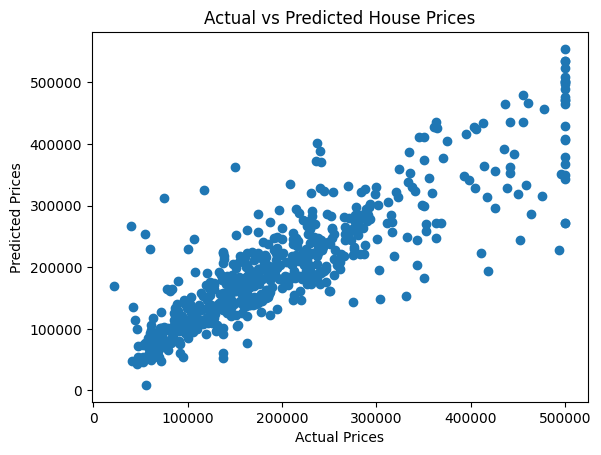

In [176]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()